                                PPROJECT TITLE 
        Promotion Strategy Optimization in Retail Pharmacy 
                     Case Study: COMPANY X(Feb – May 2026)

Excetive  Summary:

This project evaluates the efficiency of promotional strategies within a retail pharmacy environment.

 I focused on identifying categories that are heavily discounted without clear strategic justification, as well as seasonal patterns in discounting behavior.
 
Due to the absence of sales volume data, I reframed the analysis to assess promotional intensity and potential margin risk, using discount depth as a proxy. The goal was to highlight areas where the business may be over-discounting and recommend tighter promotion control to protect profitability.

The outcome is a decision-support framework for improving promotional governance and reducing unnecessary margin exposure.

Project Objectives:

detecting  inefficient promotion structures, and recommend strategies to optimize profitability while maintaining customer traffic.

Company X operates in a highly competitive, price-sensitive environment, where promotions are a key lever to:

Increase store traffic
Expand basket size
Defend market share against competitors

However, without robust optimization, promotions can create a false sense of growth—increasing revenue while silently eroding profitability.

1.Promotion Strategy Diagnostics

-Identifing dominant promotion types (e.g., % discount, bundle, BOGO)

-Evaluating distribution across categories and brands

-Identify categories with excessive promotional exposure

2.Discount Depth analysis

3.Evaluation of Promotion Effectiveness by Product Category

4.Gain Made by Customers vs Loss to Company


    -Customer savings (discount captured)

    -Company revenue sacrificed


Who benefits more — the customer or the business?




Data Constraints Acknowledgment 

Due to the absence of cost and customer-level data, the analysis focuses on proxy indicators of profitability, including:




If provided with a complete dataset, I would reposition the analysis into two strategic pillars: product-centric performance and customer-centric behavior, ensuring both commercial impact and long-term sustainability are addressed.

On the product (or promotion) side, I would reframe the evaluation of promotional effectiveness around three core financial metrics: incremental sales uplift, margin impact, and promotion ROI. The first step would be to construct a robust baseline model to estimate expected sales in the absence of promotions, enabling a clear measurement of true incremental uplift. I would then quantify the margin trade-off by assessing whether the additional revenue generated sufficiently compensates for the discount-driven margin erosion. Building on this, I would implement a structured decision framework (e.g., a performance matrix) to segment promotions into high-performing, neutral, and value-destructive categories. This would allow the business to systematically scale profitable promotions, optimize borderline campaigns, and eliminate those that fail to generate sustainable value.

On the customer side, I would redesign the analysis using an RFM  framework to develop a deeper understanding of customer behavior and loyalty dynamics. This segmentation would help identify high-value loyal customers, promotion-dependent segments, and those at risk of churn. More importantly, it would enable the business to assess price sensitivity and promotion dependency, highlighting which customer groups are likely to disengage if discounts are reduced or removed. These insights can then inform more targeted and personalized promotion strategies, reducing unnecessary discounting while preserving customer retention and lifetime value.

Together, these two perspectives create a more holistic strategy while balancing short-term promotional gains with long-term customer equity and profitability.

In [279]:
import pandas as pd
import numpy as np

import glob
import os

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px





In [280]:
def load_files(folder_path):

    df_list = []

    for file in os.listdir(folder_path):

        file_path = os.path.join(r"C:\Users\PAVILION PLUS\Desktop\COMPANY_X   analysis", file)

        try:

            if file.endswith(".csv"):
                df = pd.read_csv(file_path)

            elif file.endswith(".xlsx"):
                df = pd.read_excel(file_path)
            elif file.endswith('.js'):
                df=pd.read_json(file_path)
            elif file.endswith('.txt'):
                df=pd.read_table(file_path)

            else:
                continue

            df['source_file'] = file
            df_list.append(df)

            print(f"{file} loaded successfully")

        except Exception as e:
            print(f"Error loading {file}: {e}")

    return pd.concat(df_list, ignore_index=True)


In [281]:
df = load_files(r"C:\Users\PAVILION PLUS\Desktop\COMPANY_X   analysis")
df

APRIL.xlsx loaded successfully
FEBRUARY.xlsx loaded successfully
JUNE.xlsx loaded successfully
MARCH.xlsx loaded successfully
MAY.xlsx loaded successfully


,Division,Department,Category,Item Brand,Period,Channel,Group_Code,ITEM,English Description,OFFER TYPE,Price with VAT,Promo Price with VAT,Saving,Depth%,START_DATE,END_DATE,source_file,Hero
0,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103184367,Christian Dior miss dior EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx,NaN
1,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183866,Christian Dior sauvage Perfume 200 ml,Direct_Discount,1054.57,843.70,210.0,0.200000,2026-04-01,2026-04-30,APRIL.xlsx,NaN
2,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183807,Christian Dior pure poison EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx,NaN
3,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103181908,Christian Dior dior homme intense EDP150 ml,Direct_Discount,725.86,580.70,145.0,0.200000,2026-04-01,2026-04-30,APRIL.xlsx,NaN
4,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183129,Christian Dior hypnotic poison EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37489,WELLNESS,NUTRACEUTICALS AND NUTRITION,SPORTS AND FITNESS,Born Winner,Full,BM only,1_230589,102476747,Bw Mega Pro Protein Bar Waffle With Chocolate ...,BUY 1 GET 1 WITH PERCENT OFF 50,30.03,22.55,7.0,NaN,2026-05-01,2026-05-31,MAY.xlsx,PL
37490,WELLNESS,NUTRACEUTICALS AND NUTRITION,HEALTHY NUTRITION,True Honey,Full,BM only,1_230589,103379017,Manuka Truehoney Rare Harvest Mgo 2050 - 230 Gm,BUY 1 GET 1 WITH PERCENT OFF 50,10041.65,7531.25,2510.0,NaN,2026-05-01,2026-05-31,MAY.xlsx,PL
37491,WELLNESS,NUTRACEUTICALS AND NUTRITION,SPORTS AND FITNESS,Eric Favre,Full,BM only,1_230589,102028709,Eric Favre Mass Gainer Vanille 3kg,BUY 1 GET 1 WITH PERCENT OFF 50,401.10,300.85,100.0,NaN,2026-05-01,2026-05-31,MAY.xlsx,PL
37492,WELLNESS,NUTRACEUTICALS AND NUTRITION,SPORTS AND FITNESS,Born Winner,Full,BM only,1_230589,102476712,Bw Keto Bar Italian Creme 60 Gm,BUY 1 GET 1 WITH PERCENT OFF 50,27.38,20.55,6.0,NaN,2026-05-01,2026-05-31,MAY.xlsx,PL


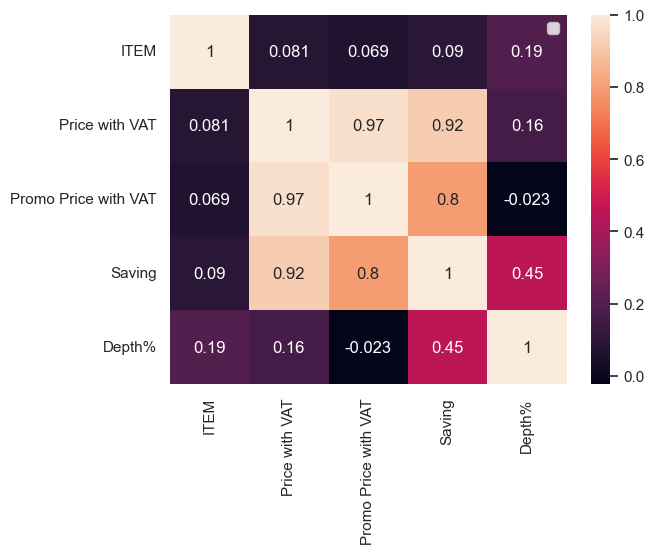

In [282]:
data_corr=df.corr(numeric_only=True)
sns.heatmap(data_corr,annot=True)
plt.legend('numerical correction')
plt.show()

In [283]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors='coerce')

FEATURE ENGINEERING

In [284]:
#Promotion Duration
df['Promo_Duration'] = (df['END_DATE'] - df['START_DATE']).dt.days

#Discount Percentage
df['Calculated_Discount'] = (df['Price with VAT'] - df['Promo Price with VAT']) / df['Price with VAT']*100

#Price Reduction
df['Price_Reduction'] = df['Price with VAT'] - df['Promo Price with VAT']

#Discount Depth
df['Discount_Depth'] = df['Saving'] / df['Price with VAT'] 

#Price Category
df['Price_Category'] = pd.qcut(df['Price with VAT'], q=4, labels=['Low','Medium','High','Premium'])

#calculated distance category
df['Calculated_Discount_catrgory']  = pd.qcut(df['Calculated_Discount'], q=3, labels=['Low','High','Premium'])

#Promotion Month
df['Promo_Month'] = df['START_DATE'].dt.month



#"corrected_Depth%"
mapping = {
    'BUY 2 GET 1 FREE ': 1,
    'BUY 1 GET 1 FREE ': 1,
    'BUY 2 GET 2 FREE ':2,
    'BUY 1 GET 1 WITH PERCENT OFF 30':.30, 
    'BUY 1 GET 1 WITH PERCENT OFF 40':.40,
    'BUY 1 GET 1 WITH PERCENT OFF 50':.50,
    'BUY 1 GET 1 WITH PERCENT OFF 60':.60,
    'BUY 1 GET 1 WITH PERCENT OFF 70':.70,
    'BUY 1 GET 2 FREE ':2,
    '(B/G) BUY 2 GET 1 FREE ':1,
    'BUY 1 GET 1 WITH PERCENT OFF 70': .30

}

df["corrected_Depth%"] = df.apply( lambda row: mapping[row["OFFER TYPE"]] if row["OFFER TYPE"] in mapping else row["Depth%"], axis=1)

# Promotion Risk Score
df['Promo_Risk_Score'] = df['corrected_Depth%'] * df['Promo_Duration']

#LABELS
mapping = {
    'Accez':'PL',
    'Active Go':'PL',
    'Alfoshan':'PL',
    'ALmisan':'PL', 
    'AURI':'PL',
    'Babygee':'PL',
    'Babywell':'PL',
    'Beatswell':'PL',
    'Bibi':'PL',
    'Bio-Synergy':'PL',
    'Blade':'PL',
    'Body Spa':'PL',
    'BODYLICIOUS':'PL',
    'Boutique':'PL',
    'Citizen':'PL',
    'Clary':'PL',
    'Clevie':'PL',
    'Clevie Derma':'PL',
    'Connect':'PL',
    'COXIR':'PL',
    'Creigtons':'PL',
    'Davids':'PL',
    'Emotion':'PL',
    'Eric Favre':'PL',
    'Febella':'PL',
    'First Aids Kit':'PL',
    'Footness':'PL',
    'Fragrances For Her':'PL',
    'Fruit Works':'PL',
    'Gamar':'PL',
    'Grit':'PL',
    'I Kuzma':'PL',
    'Kaiyang':'PL',
    'Keller':'PL',
    'Killys':'PL',
    'Mades':'PL',
    'Martini':'PL',
    'Medex':'PL',
    'Molfix':'PL',
    'Movera':'PL',
    'Movera Ortho':'PL',
    'Movera Sport':'PL',
    'MUVU':'PL',
    'Nahdi':'PL',
    'NUTSHELL':'PL',
    'OE':'PL',
    'OnCall':'PL',
    'Orex':'PL',
    'Parsa':'PL',
    'Parsa Beauty':'PL',
    'Qure':'PL',
    'Rosal':'PL',
    'Sanotact':'PL',
    'Shadez':'PL',
    'True Honey':'PL',
    'Velveta':'PL',
    'Viora':'PL',
    'Yunmai':'PL',
    'Yuwell':'PL',
    'ZAK':'PL'

}
df["LABELS"] = df.apply( lambda row: mapping[row["Item Brand"]] if row["Item Brand"] in mapping else 'OTHERS', axis=1)


DETAILING OF OBJECTIVES

# OBJECTIVE 1.Promotion Strategy Diagnostics

Promotion Types Distribution
OFFER TYPE
Direct_Discount                    29.188670
BUY 2 GET 1 FREE                   23.267723
BUY 1 GET 1 FREE                   16.906705
BUY 1 GET 1 WITH PERCENT OFF 50    10.439004
BUY 1 GET 1 WITH PERCENT OFF 40     9.038780
BUY 2 GET 2 FREE                    8.326666
BUY 1 GET 1 WITH PERCENT OFF 30     1.546914
BUY 1 GET 2 FREE                    0.786793
BUY 1 GET 1 WITH PERCENT OFF 60     0.426735
(B/G) BUY 2 GET 1 FREE              0.045341
BUY 1 GET 1 WITH PERCENT OFF 70     0.026671
Name: proportion, dtype: float64


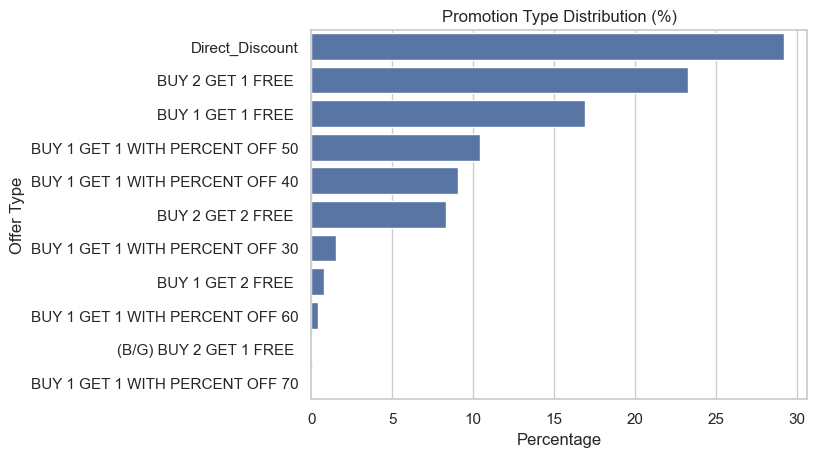

In [285]:
#1.1 Dominant Promotion Types
promo_dist = df['OFFER TYPE'].value_counts(normalize=True) * 100
print('Promotion Types Distribution')
print(promo_dist)

sns.barplot(x=promo_dist.values, y=promo_dist.index)
plt.title("Promotion Type Distribution (%)")
plt.xlabel("Percentage")
plt.ylabel("Offer Type")
plt.show()

In [286]:
#1.2
promo_dist_month = df.groupby('Promo_Month')['OFFER TYPE'].value_counts(normalize=True) * 100
promo_dist_month

Promo_Month  OFFER TYPE                     
2            BUY 2 GET 1 FREE                   27.146320
             BUY 2 GET 2 FREE                   24.837352
             Direct_Discount                    20.653145
             BUY 1 GET 1 FREE                   19.874984
             BUY 1 GET 1 WITH PERCENT OFF 50     5.931879
             BUY 1 GET 1 WITH PERCENT OFF 30     0.650593
             BUY 1 GET 1 WITH PERCENT OFF 60     0.331675
             BUY 1 GET 2 FREE                    0.306162
             (B/G) BUY 2 GET 1 FREE              0.140324
             BUY 1 GET 1 WITH PERCENT OFF 70     0.127567
3            Direct_Discount                    30.292490
             BUY 1 GET 1 WITH PERCENT OFF 40    25.849802
             BUY 1 GET 1 WITH PERCENT OFF 50    18.134387
             BUY 2 GET 1 FREE                   16.079051
             BUY 1 GET 1 FREE                    8.537549
             BUY 1 GET 2 FREE                    0.474308
             BUY 1 GET 1 WI

In [287]:
#1.3
promo_dist_month_labels = df.groupby(['LABELS','Promo_Month'])['OFFER TYPE'].value_counts(normalize=True) * 100
promo_dist_month_labels

LABELS  Promo_Month  OFFER TYPE                     
OTHERS  2            BUY 2 GET 1 FREE                   31.775422
                     BUY 2 GET 2 FREE                   29.072719
                     Direct_Discount                    18.605346
                     BUY 1 GET 1 FREE                   12.154696
                     BUY 1 GET 1 WITH PERCENT OFF 50     6.809019
                     BUY 1 GET 1 WITH PERCENT OFF 30     0.761535
                     BUY 1 GET 1 WITH PERCENT OFF 60     0.388234
                     BUY 1 GET 2 FREE                    0.358369
                     (B/G) BUY 2 GET 1 FREE              0.074660
        3            BUY 1 GET 1 WITH PERCENT OFF 40    31.273910
                     Direct_Discount                    29.648049
                     BUY 2 GET 1 FREE                   19.452946
                     BUY 1 GET 1 FREE                    9.429992
                     BUY 1 GET 1 WITH PERCENT OFF 50     8.856159
                     BU

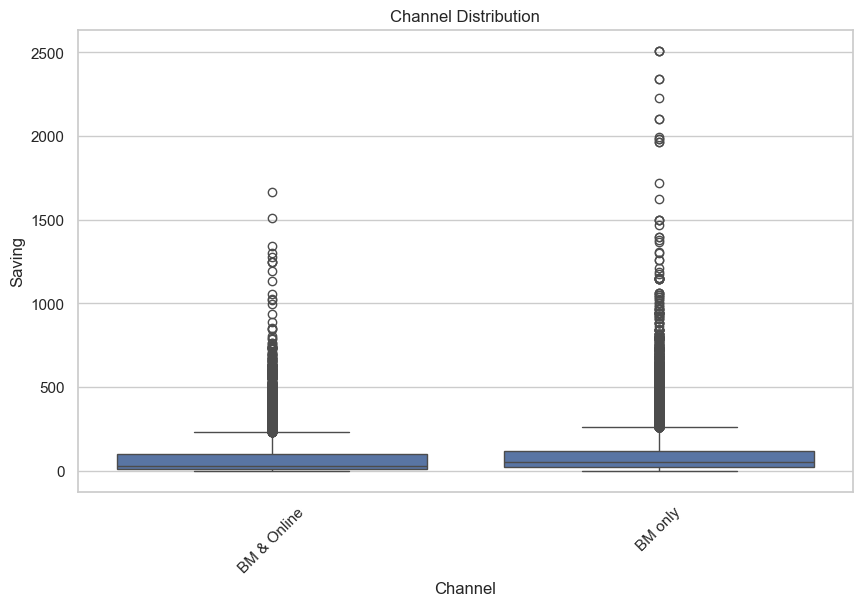

In [288]:
#1.4
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Channel', y='Saving')
plt.title("Channel Distribution")
plt.xticks(rotation=45)
plt.show()

In [289]:
#1.5 Distribution Across Categories & Brands

category_promo = pd.crosstab(df['Category'], df['OFFER TYPE'], normalize='index') * 100
brand_promo = pd.crosstab(df['Item Brand'], df['OFFER TYPE'], normalize='index') * 100

print(category_promo)


OFFER TYPE               (B/G) BUY 2 GET 1 FREE   BUY 1 GET 1 FREE   \
Category                                                              
ADVANCED ORAL CARE                      0.000000          26.000000   
BABY FOOD                               0.000000           0.000000   
BABY MILK                               0.000000           0.000000   
BABY TOILETRIES                         0.000000           2.645503   
BABY WIPES                              0.000000           0.000000   
BATH AND SHOWER                         0.000000          32.051282   
BEAUTY ACCESSORIES                      0.000000          39.940719   
BEAUTY SKIN CARE                        0.000000          23.308271   
BODY FRESHENERS                         0.000000          52.333333   
BODY MOISTURIZERS                       0.000000          44.112150   
BODY SUPPORT                            0.000000           0.000000   
BREATH FRESHENER                        0.000000          10.810811   
CLEAN 

In [290]:
print(brand_promo)

OFFER TYPE      (B/G) BUY 2 GET 1 FREE   BUY 1 GET 1 FREE   \
Item Brand                                                   
21St Century                        0.0          41.666667   
7Elements                           0.0          33.333333   
ACM                                 0.0          49.565217   
ADDITIVA                            0.0           0.000000   
ALPECIN                             0.0           0.000000   
...                                 ...                ...   
ZAK                                 0.0          60.000000   
ZO Skin Health                      0.0          33.333333   
Zartaux                             0.0          20.000000   
Zerostat                            0.0           0.000000   
olaplex                             0.0         100.000000   

OFFER TYPE      BUY 1 GET 1 WITH PERCENT OFF 30  \
Item Brand                                        
21St Century                                0.0   
7Elements                               

In [291]:
#1.6 Over-Reliance on Margin-Eroding Promotions

high_discount_threshold = df['corrected_Depth%'].quantile(0.75)

high_discount_ratio = (
    df[df['corrected_Depth%'] > high_discount_threshold]
    .groupby('Category')
    .size() / df.groupby('Category').size()
).fillna(0)

print(high_discount_ratio.sort_values(ascending=False))

Category
NAILS                      0.602356
MAKEUP                     0.362777
HAIR TREATMENT             0.167742
MEN GROOMING               0.149254
DERMO SKIN CARE            0.147284
BEAUTY SKIN CARE           0.144044
DERMA CARE                 0.090909
HAIR COLOR                 0.078740
PAIN MANAGEMENT            0.071429
HEALTHY NUTRITION          0.062147
BABY TOILETRIES            0.041005
HAIR REMOVALS              0.039146
MOUTHWASH                  0.037037
BATH AND SHOWER            0.033800
SPORTS AND FITNESS         0.030710
WOMEN HEALTH               0.030508
HAND HYGIENE               0.030364
BREATH FRESHENER           0.027027
GENERAL HEALTH             0.027015
CLEAN HAIR CARE            0.020725
MEN HEALTH                 0.019830
INTIMATE HYGIENE           0.019084
DEODORANTS                 0.014241
REGULAR SKIN CARE          0.013126
PROFESSIONAL HAIR CARE     0.012158
TOOTHPASTE                 0.009174
ADVANCED ORAL CARE         0.004000
LIFESTYLE          

In [292]:
#1.7  CATEGORY-LEVEL ANALYSIS

category_analysis = df.groupby('Category').agg({
    'corrected_Depth%': 'mean',
    'Promo_Risk_Score': 'mean',
    'ITEM': 'count'
}).rename(columns={'ITEM': 'Promo_Frequency'}).reset_index().sort_values(by='Promo_Risk_Score', ascending=False)

category_analysis 

,Category,corrected_Depth%,Promo_Risk_Score,Promo_Frequency
44,NAILS,1.559057,43.803599,679
37,MAKEUP,1.240944,34.889493,3068
39,MEN GROOMING,1.002551,29.133681,67
17,DERMO SKIN CARE,0.927211,26.734422,5099
12,CLEAN HAIR CARE,0.866322,25.208301,193
31,HOME HYGIENE,0.909091,25.181818,11
29,HAND HYGIENE,0.874191,25.132519,494
28,HAIR TREATMENT,0.861532,24.632824,620
52,SANITARY CARE,0.853846,24.427350,117
5,BATH AND SHOWER,0.837992,24.315101,858


In [293]:
#1.8 Sort by risk
category_analysis = category_analysis.sort_values(by='Promo_Risk_Score', ascending=False)

print("\n=== CATEGORY PROMOTION ANALYSIS ===")
print(category_analysis.head(10))


=== CATEGORY PROMOTION ANALYSIS ===
           Category  corrected_Depth%  Promo_Risk_Score  Promo_Frequency
44            NAILS          1.559057         43.803599              679
37           MAKEUP          1.240944         34.889493             3068
39     MEN GROOMING          1.002551         29.133681               67
17  DERMO SKIN CARE          0.927211         26.734422             5099
12  CLEAN HAIR CARE          0.866322         25.208301              193
31     HOME HYGIENE          0.909091         25.181818               11
29     HAND HYGIENE          0.874191         25.132519              494
28   HAIR TREATMENT          0.861532         24.632824              620
52    SANITARY CARE          0.853846         24.427350              117
5   BATH AND SHOWER          0.837992         24.315101              858


In [294]:
#1.9 concept of carnibalization in the analysis

# 1. The use of  'median' instead of 'mean' to protect against Month 2's crazy numbers
item_metrics = df.groupby('ITEM').agg(
    unique_months=('Promo_Month', 'nunique'),
    avg_discount=('corrected_Depth%', 'median')  # <-- CHANGED TO MEDIAN
).reset_index()

# 2. Get dynamic thresholds from the item-level summary
# (Top 25% of items by frequency, and Top 25% of items by average depth)
freq_threshold = item_metrics['unique_months'].quantile(0.75)
depth_threshold = item_metrics['avg_discount'].quantile(0.75)

# 3. Filter the summary dataframe for items that exceed BOTH thresholds
cannibal_items = item_metrics[
    (item_metrics['unique_months'] >= freq_threshold) & 
    (item_metrics['avg_discount'] >= depth_threshold)
]['ITEM']

# 4. Map the flag back to your original dataframe
df['Cannibalization_Risk_Flag'] = df['ITEM'].isin(cannibal_items).astype(int)

# 5. Quick check to see how many items were flagged
print(f"Number of flagged items: {df['Cannibalization_Risk_Flag'].sum()}")

Number of flagged items: 7408


In [295]:
#2.0 Select the columns you want to inspect
columns_to_show = ['ITEM', 'English Description', 'Category', 'corrected_Depth%', 'Promo_Month']

# Filter and display the unique combinations
flagged_details = df[df['Cannibalization_Risk_Flag'] == 1][columns_to_show].drop_duplicates(subset=['ITEM'])

# Display the dataframe
print(flagged_details)


           ITEM                                English Description  \
472   103076788               Ego Qv Face Oil Free Moisturiser 75g   
473   100576672                 EGO QV Face Gentle Cleanser 250 gm   
475   101397203         Ego Qv Face Gentle Foaming Cleanser 150 ml   
477   103076761            Ego Qv Face Oil Free Gel Cleanser 200ml   
479   103076753        Ego Qv Face Oil Free Foaming Cleanser 150ml   
...         ...                                                ...   
6780  102234692  Beatswell Vitamin C + Zinc 20 Effervescent Tab...   
6781  102209657  Beatswell Iron + Vitamin C 20 Effervescent Tab...   
6783  102499615  Beatswell Calcium + Mg + D3 15 Effervescent Ta...   
6784  102525668  Beatswell Multivitamin Energy 20 Effervescent ...   
6792  102209673     Beatswell Multivitamin 20 Effervescent Tablets   

             Category  corrected_Depth%  Promo_Month  
472   DERMO SKIN CARE          0.249958            4  
473   DERMO SKIN CARE          0.250000          

In [296]:
#2.1 Export the flagged details to an Excel file
flagged_details.to_csv('cannibalization_risk_items.csv', index=False)
print("Saved flagged items to 'cannibalization_risk_items.csv'")

Saved flagged items to 'cannibalization_risk_items.csv'


In [297]:
#2.2 Check the average discount depth per month
print("Average Discount Depth by Month:")
print(df.groupby('Promo_Month')['corrected_Depth%'].mean())

# Check how many unique items were discounted in each month
print("\nNumber of Unique Items Discounted by Month:")
print(df.groupby('Promo_Month')['ITEM'].nunique())

Average Discount Depth by Month:
Promo_Month
2    1.076818
3    0.556846
4    0.665545
5    0.592752
6    0.896507
Name: corrected_Depth%, dtype: float64

Number of Unique Items Discounted by Month:
Promo_Month
2    7677
3    6325
4    6777
5    7105
6    8835
Name: ITEM, dtype: int64


In [298]:
# 2.3. Filtering of  the dataframe to ONLY show  flagged risk items
flagged_df = df[df['Cannibalization_Risk_Flag'] == 1]

# 2. Pivot the data to see how these specific items are spread across months
monthly_distribution = flagged_df.groupby('Promo_Month')['ITEM'].count()

print("--- Distribution of Flagged Items Across All Months ---")
print(monthly_distribution)

--- Distribution of Flagged Items Across All Months ---
Promo_Month
2    1443
3    1443
4    1443
5    1635
6    1444
Name: ITEM, dtype: int64


In [299]:
# 2.4. Filter for rows matching our flagged items
flagged_df = df[df['Cannibalization_Risk_Flag'] == 1]

# 2. Group by ITEM to find those that appear in Months 2, 3,4,5,6
# (We filter for items that have a count of 3 or more across those specific months)
core_months = [2, 3, 4,5,6]
core_flagged_df = flagged_df[flagged_df['Promo_Month'].isin(core_months)]
item_month_counts = core_flagged_df.groupby('ITEM')['Promo_Month'].nunique()

core_item_ids = item_month_counts[item_month_counts == len(core_months)].index

# 3. Extract clean details for these 1444 items
columns_to_extract = ['Division', 'Department', 'Category', 'Item Brand', 'ITEM', 'English Description']
chronic_offenders = df[df['ITEM'].isin(core_item_ids)][columns_to_extract].drop_duplicates(subset=['ITEM'])

# 4. View the total and the first few items
print(f"Successfully extracted {len(chronic_offenders)} core chronic items.")
print("\nFirst 10 Chronic Offenders:")
print(chronic_offenders.head(10))

Successfully extracted 1443 core chronic items.

First 10 Chronic Offenders:
         Division                 Department         Category    Item Brand  \
472        BEAUTY                  SKIN CARE  DERMO SKIN CARE           Ego   
473        BEAUTY                  SKIN CARE  DERMO SKIN CARE           Ego   
475        BEAUTY                  SKIN CARE  DERMO SKIN CARE           Ego   
477        BEAUTY                  SKIN CARE  DERMO SKIN CARE           Ego   
479        BEAUTY                  SKIN CARE  DERMO SKIN CARE           Ego   
480        BEAUTY                  SKIN CARE  DERMO SKIN CARE           Ego   
824  MOM AND BABY  BABY TOILETRIES AND WIPES  BABY TOILETRIES  Johnson Baby   
825  MOM AND BABY  BABY TOILETRIES AND WIPES  BABY TOILETRIES  Johnson Baby   
826  MOM AND BABY  BABY TOILETRIES AND WIPES  BABY TOILETRIES  Johnson Baby   
827  MOM AND BABY  BABY TOILETRIES AND WIPES       BABY WIPES  Johnson Baby   

          ITEM                                English

In [300]:
#2.5
chronic_offenders.to_csv('chronic_promo_offenders_1444.csv', index=False)

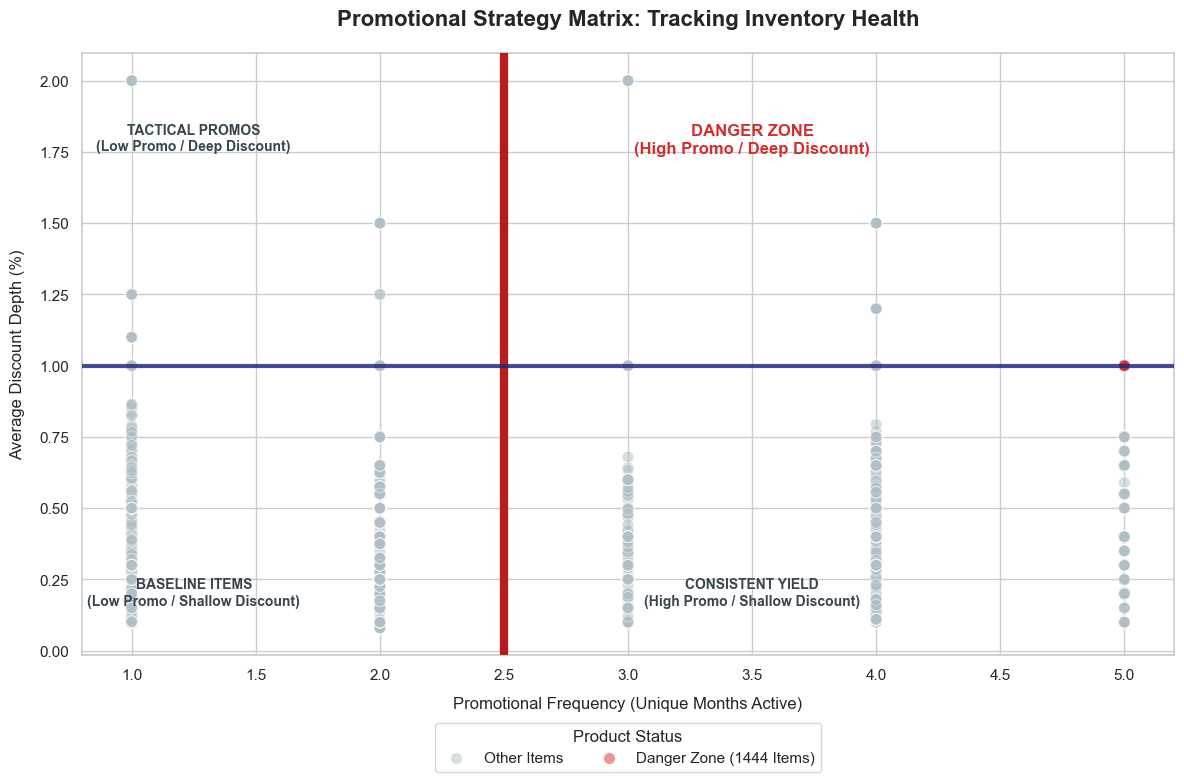

In [301]:
#2.6 Prepare the plotting data using our previous item_metrics dataframe
plot_data = item_metrics.copy()

plot_data['Quadrant_Label'] = 'Other Items'
plot_data.loc[plot_data['ITEM'].isin(core_item_ids), 'Quadrant_Label'] = 'Danger Zone (1444 Items)'

# 2. Set up the plotting style
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 3. Create the scatter plot
ax = sns.scatterplot(
    data=plot_data,
    x='unique_months',
    y='avg_discount',
    hue='Quadrant_Label',
    palette={'Other Items': '#b0bec5', 'Danger Zone (1444 Items)': '#d32f2f'},
    alpha=0.5,
    s=70,
    zorder=3 # Keeps dots in the middle layer
)

# 4. FIXED DEMARCATION LINES
# Hardcode the vertical line at 2.5 instead of using freq_threshold
# Made it solid (-), extra thick (linewidth=6), and bright red (#b71c1c)
ax.axvline(x=2.5, color='#b71c1c', linestyle='-', linewidth=6, alpha=1.0, zorder=5)

# Horizontal Line (Kept at your depth threshold, but made solid and distinct)
ax.axhline(y=depth_threshold, color='#1a237e', linestyle='-', linewidth=3, alpha=0.8, zorder=5)

# 5. Adjusted Text Coordinates to match the new 2.5 split
# Danger Zone (Top Right)
plt.text(3.5, 1.85, "DANGER ZONE\n(High Promo / Deep Discount)", 
         color='#d32f2f', fontsize=12, weight='bold', ha='center', va='top', zorder=6)

# Tactical Promos (Top Left)
plt.text(1.25, 1.85, "TACTICAL PROMOS\n(Low Promo / Deep Discount)", 
         color='#37474f', fontsize=10, weight='bold', ha='center', va='top', zorder=6)

# Consistent Yield (Bottom Right)
plt.text(3.5, 0.15, "CONSISTENT YIELD\n(High Promo / Shallow Discount)", 
         color='#37474f', fontsize=10, weight='bold', ha='center', va='bottom', zorder=6)

# Baseline Items (Bottom Left)
plt.text(1.25, 0.15, "BASELINE ITEMS\n(Low Promo / Shallow Discount)", 
         color='#37474f', fontsize=10, weight='bold', ha='center', va='bottom', zorder=6)
# 6. Final chart formatting
plt.title("Promotional Strategy Matrix: Tracking Inventory Health", fontsize=16, pad=20, weight='bold')
plt.xlabel("Promotional Frequency (Unique Months Active)", fontsize=12, labelpad=10)
plt.ylabel("Average Discount Depth (%)", fontsize=12, labelpad=10)
plt.legend(title="Product Status", loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=11)

plt.tight_layout()

# Save the plot image
plt.savefig('promotional_danger_zone_matrix_bold.png', dpi=300)
plt.show()



In [302]:
# 2.7. Filter using your exact dataset column names and floating-point tolerance
red_dot_item_safe = df[
    (df['Promo_Month'] == 4.0) & 
    (np.isclose(df['corrected_Depth%'], 1.00, atol=1e-5))
]

# 2. Export the filtered item(s) to a CSV file
# 'index=False' prevents pandas from writing an unnamed row index column into your CSV
output_file = 'red_dot_item_extract.csv'
red_dot_item_safe.to_csv(output_file, index=False)

print(f"Successfully extracted {len(red_dot_item_safe)} item(s) and saved to '{output_file}'!")

Successfully extracted 3141 item(s) and saved to 'red_dot_item_extract.csv'!


# OBJECTIVE 2.Discount Depth 

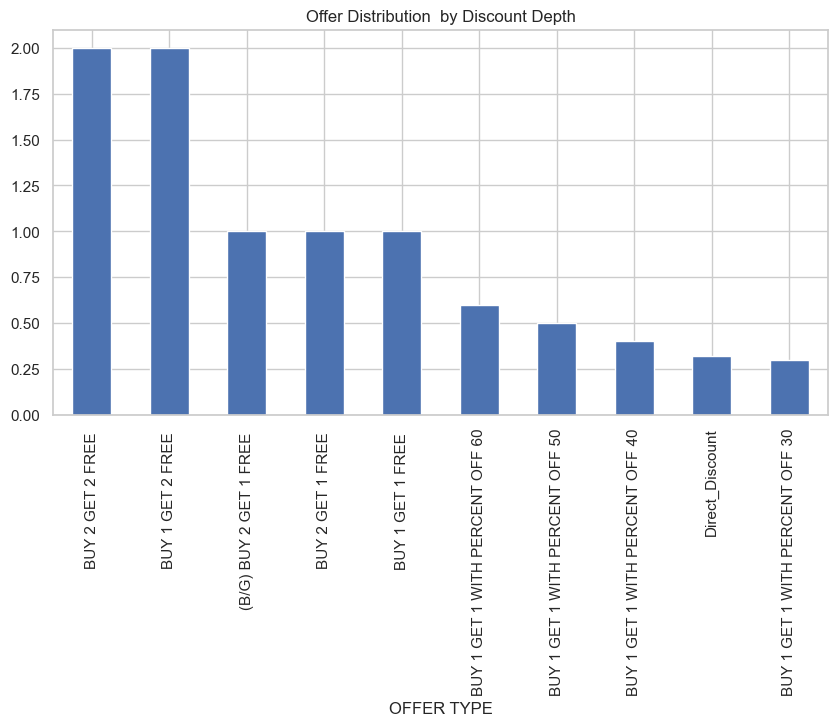

In [303]:
#2.1 discounting depth as per offer type
offer_distribution = (
    df.groupby('OFFER TYPE')['corrected_Depth%']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

offer_distribution.plot(kind='bar', figsize=(10,5), title='Offer Distribution  by Discount Depth')
plt.show()

In [304]:
#2.1 IDENTIFY OVER-PROMOTED CATEGORIES
# Thresholds 
high_discount_threshold = df['corrected_Depth%'].quantile(0.75)
high_frequency_threshold = category_analysis['Promo_Frequency'].quantile(0.75)

category_analysis['Risk_Level'] = np.where(
    (category_analysis['corrected_Depth%'] > high_discount_threshold) &
    (category_analysis['Promo_Frequency'] > high_frequency_threshold),
    'Critical',
    np.where(
        (category_analysis['corrected_Depth%'] > high_discount_threshold),
        'Moderate',
        'Low'
    )
)

print("\n=== RISK CLASSIFICATION ===")
print(category_analysis[['Category', 'Risk_Level']].head(10))





=== RISK CLASSIFICATION ===
           Category Risk_Level
44            NAILS   Critical
37           MAKEUP   Critical
39     MEN GROOMING   Moderate
17  DERMO SKIN CARE        Low
12  CLEAN HAIR CARE        Low
31     HOME HYGIENE        Low
29     HAND HYGIENE        Low
28   HAIR TREATMENT        Low
52    SANITARY CARE        Low
5   BATH AND SHOWER        Low


In [305]:
# DECISION FRAMEWORK

def decision_rule(row):
    if row['Risk_Level'] == 'Critical':
        return 'Reduce or Stop Promotions'
    elif row['Risk_Level'] == 'Moderate':
        return 'Optimize Discount Strategy'
    else:
        return 'Maintain Strategy'

category_analysis['Recommended_Action'] = category_analysis.apply(decision_rule, axis=1)

print("\n=== FINAL RECOMMENDATIONS ===")
print(category_analysis[['Category', 'Risk_Level', 'Recommended_Action']])


=== FINAL RECOMMENDATIONS ===
                   Category Risk_Level          Recommended_Action
44                    NAILS   Critical   Reduce or Stop Promotions
37                   MAKEUP   Critical   Reduce or Stop Promotions
39             MEN GROOMING   Moderate  Optimize Discount Strategy
17          DERMO SKIN CARE        Low           Maintain Strategy
12          CLEAN HAIR CARE        Low           Maintain Strategy
31             HOME HYGIENE        Low           Maintain Strategy
29             HAND HYGIENE        Low           Maintain Strategy
28           HAIR TREATMENT        Low           Maintain Strategy
52            SANITARY CARE        Low           Maintain Strategy
5           BATH AND SHOWER        Low           Maintain Strategy
7          BEAUTY SKIN CARE        Low           Maintain Strategy
47          PAIN MANAGEMENT        Low           Maintain Strategy
8           BODY FRESHENERS        Low           Maintain Strategy
6        BEAUTY ACCESSORIES    

# OBJECTIVE 3.Evaluation of Promotion Effectiveness by Product Category

In [306]:
df.groupby('LABELS').agg({'corrected_Depth%':'sum','Saving':'sum','Promo Price with VAT':'mean'})

,corrected_Depth%,Saving,Promo Price with VAT
LABELS,,,
OTHERS,25153.026973,3310912.0,181.580697
PL,3819.701511,200196.0,63.318114


In [307]:
df.groupby(['LABELS','OFFER TYPE'])['OFFER TYPE'].count()

LABELS  OFFER TYPE                     
OTHERS  (B/G) BUY 2 GET 1 FREE                5
        BUY 1 GET 1 FREE                   4224
        BUY 1 GET 1 WITH PERCENT OFF 30     580
        BUY 1 GET 1 WITH PERCENT OFF 40    3389
        BUY 1 GET 1 WITH PERCENT OFF 50    2530
        BUY 1 GET 1 WITH PERCENT OFF 60     160
        BUY 1 GET 2 FREE                    289
        BUY 2 GET 1 FREE                   8479
        BUY 2 GET 2 FREE                   3122
        Direct_Discount                    8792
PL      (B/G) BUY 2 GET 1 FREE               12
        BUY 1 GET 1 FREE                   2115
        BUY 1 GET 1 WITH PERCENT OFF 50    1384
        BUY 1 GET 1 WITH PERCENT OFF 70      10
        BUY 1 GET 2 FREE                      6
        BUY 2 GET 1 FREE                    245
        Direct_Discount                    2152
Name: OFFER TYPE, dtype: int64

# OBJECTIVE 4.Gain Made by Customers vs Loss to Company

In [308]:
#4.1 Customer Savings

total_customer_savings = df['Saving'].sum()

print('Customer Savings:')
print(total_customer_savings)

Customer Savings:
3511108.0


In [309]:
total_customer__monthly_savings = df.groupby('Promo_Month')['Saving'].sum()
total_customer__monthly_savings



Promo_Month
2     869627.0
3     475654.0
4     559369.0
5     538153.0
6    1068305.0
Name: Saving, dtype: float64

In [310]:
#4.2 Company Revenue Sacrifice
total_revenue_sacrifice = (df['Price with VAT'] - df['Promo Price with VAT']).sum()
print('total_revenue_sacrifice:')
print(total_revenue_sacrifice) 

total_revenue_sacrifice:
3532705.6899999995


In [311]:
#4.3 Net Value Transfer
value_transfer = pd.DataFrame({
    'Metric': ['Customer Gain', 'Company Loss'],
    'Value': [total_customer_savings, total_revenue_sacrifice]
})

print(value_transfer)

          Metric       Value
0  Customer Gain  3511108.00
1   Company Loss  3532705.69


In [312]:
#4.4 Who Benefits More?

if total_customer_savings > total_revenue_sacrifice:
    print("Customers benefit more")
else:
    print("Company retains more value")

Company retains more value


MoM Analysis

In [313]:
# MONTHLY TREND ANALYSIS
df['Month'] = df['START_DATE'].dt.month
monthly_trend = df.groupby('Month').agg({
    'corrected_Depth%': 'mean',
    'Promo_Risk_Score': 'mean'
}).reset_index()

print("\n=== MONTHLY TREND ===")
print(monthly_trend)


=== MONTHLY TREND ===
   Month  corrected_Depth%  Promo_Risk_Score
0      2          1.076818         29.074098
1      3          0.556846         16.705393
2      4          0.665545         19.300816
3      5          0.592752         17.782558
4      6          0.896507         25.998705


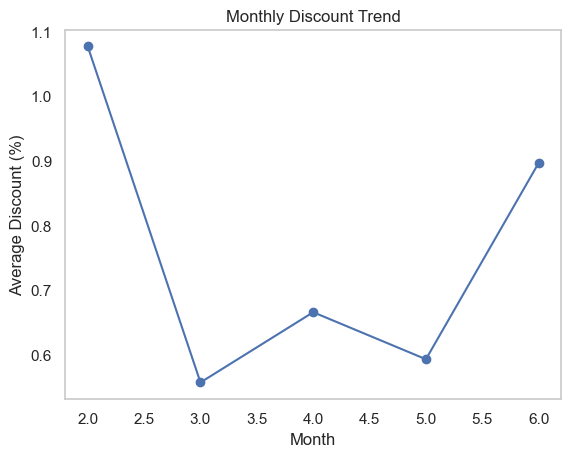

In [314]:
# 1. Monthly Discount Trend
plt.figure()
plt.plot(monthly_trend['Month'], monthly_trend['corrected_Depth%'], marker='o')
plt.title("Monthly Discount Trend")
plt.xlabel("Month")
plt.ylabel("Average Discount (%)")
plt.grid()
plt.show()

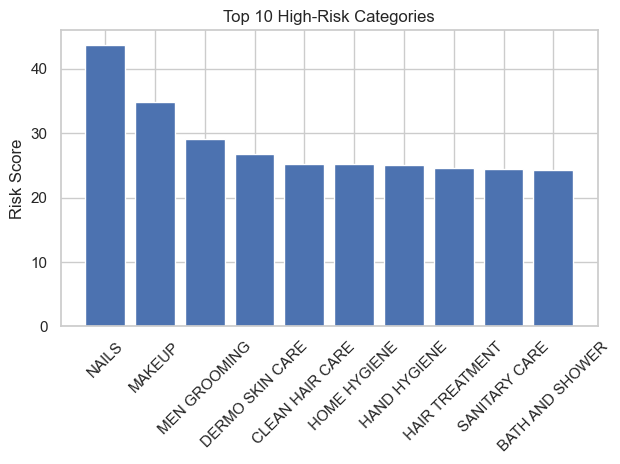

In [315]:
# 2. Top 10 Risky Categories
top_risk = category_analysis.head(10)

plt.figure()
plt.bar(top_risk['Category'], top_risk['Promo_Risk_Score'])
plt.title("Top 10 High-Risk Categories")
plt.xticks(rotation=45)
plt.ylabel("Risk Score")
plt.tight_layout()
plt.show()


RECOMMENDATIONS:


1. Shift from Volume-Driven to Profit-Driven Promotions
Introduce margin guardrails for all campaigns
Avoid deep discounting without clear ROI justification
2. Optimize Discount Depth
Identify and enforce optimal discount brands per category
Reduce unnecessary over-discounting
3. Prioritize High-Margin Categories
Focus promotions on products that:
Can absorb discounts
Drive profitable basket expansion
4. Implement Promotion Performance Dashboard
Track in real-time:
Revenue vs margin impact
Discount efficiency
Category performance
5. Move Toward Data-Driven Personalization (Future Scope)
Transition from blanket promotions to:
Targeted offers

